In [1]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset as HFDataset
from evaluate import load as load_metric
from transformers import PreTrainedModel, AutoConfig

from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import DataCollatorWithPadding


from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

In [2]:
ita = pd.read_csv("dataset/train_it.csv")[["text", "label", "bio"]]

In [3]:
dataset = pd.concat([ita])

In [4]:
dataset['bio'].fillna('', inplace=True)

/tmp/ipykernel_98056/2919889901.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['bio'].fillna('', inplace=True)


In [5]:
train_df, test_df = train_test_split(
    dataset,
    test_size=0.3,
    stratify=dataset["label"],
    random_state=42
)

In [6]:
model_name = "Twitter/twhin-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
def tokenize_dual_input(batch):
    # Tokenizza la colonna 'text'
    text_encodings = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128, # Lunghezza massima per i testi
    )

    # Tokenizza la colonna 'bio'
    bio_encodings = tokenizer(
        batch["bio"],
        truncation=True,
        padding="max_length",
        max_length=64, # Possiamo usare una lunghezza diversa per le bio
    )

    # Crea un dizionario finale combinando i risultati con prefissi
    final_encodings = {}
    for key in text_encodings:
        final_encodings[f"text_{key}"] = text_encodings[key]
    
    for key in bio_encodings:
        final_encodings[f"bio_{key}"] = bio_encodings[key]
        
    return final_encodings

In [8]:
train_ds = HFDataset.from_pandas(train_df).map(tokenize_dual_input, batched=True)
test_ds = HFDataset.from_pandas(test_df).map(tokenize_dual_input, batched=True)

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [9]:
columns_to_format = [
    'text_input_ids', 'text_attention_mask',
    'bio_input_ids', 'bio_attention_mask',
    'label'
]

In [10]:
train_ds.set_format(type="torch", columns=columns_to_format)
test_ds.set_format(type="torch", columns=columns_to_format)

In [11]:
label_counts = train_df["label"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

Class weights: tensor([1.2358, 5.2414])


In [12]:

class DualEncoderForSequenceClassification(PreTrainedModel):
    # STEP 1: Specifichiamo la classe di configurazione da usare.
    # Questo risolve l'AttributeError.
    config_class = AutoConfig

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        
        # Creiamo l'architettura per i due encoder usando la configurazione.
        # In questa fase, avranno pesi casuali. Li popoleremo dopo.
        self.encoder_text = AutoModel.from_config(config)
        self.encoder_bio = AutoModel.from_config(config)

        # La nostra testa di classificazione custom
        classifier_input_size = config.hidden_size * 2
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(classifier_input_size, config.num_labels)
        
        # Questo metodo si occupa di inizializzare i pesi dei layer aggiunti (es. self.classifier)
        self.post_init()

    def forward(
        self,
        text_input_ids=None,
        text_attention_mask=None,
        bio_input_ids=None,
        bio_attention_mask=None,
        labels=None,
        return_dict=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # Ottieni gli output dai due encoder
        outputs_text = self.encoder_text(
            input_ids=text_input_ids,
            attention_mask=text_attention_mask,
            return_dict=return_dict,
        )
        outputs_bio = self.encoder_bio(
            input_ids=bio_input_ids,
            attention_mask=bio_attention_mask,
            return_dict=return_dict,
        )

        # Estrai la rappresentazione [CLS] (last_hidden_state) da ciascuno
        pooled_output_text = outputs_text.last_hidden_state[:, 0]
        pooled_output_bio = outputs_bio.last_hidden_state[:, 0]

        # Concatena le due rappresentazioni
        concatenated_output = torch.cat((pooled_output_text, pooled_output_bio), dim=1)

        # Passa attraverso la testa di classificazione
        pooled_output = self.dropout(concatenated_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            if hasattr(self.config, 'class_weights') and self.config.class_weights is not None:
                class_weights = torch.tensor(self.config.class_weights, device=self.device)
            else:
                class_weights = None
            
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            
        if not return_dict:
            output = (logits,) + (outputs_text.hidden_states, outputs_bio.hidden_states, outputs_text.attentions, outputs_bio.attentions)
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            # Puoi opzionalmente restituire anche gli hidden states e le attentions se ti servono
        )

In [13]:
config = AutoConfig.from_pretrained(model_name, num_labels=2)
config.class_weights = class_weights.tolist()
model = DualEncoderForSequenceClassification(config)

In [14]:
base_model = AutoModel.from_pretrained(model_name)
model.encoder_text.load_state_dict(base_model.state_dict())
model.encoder_bio.load_state_dict(base_model.state_dict())

Some weights of BertModel were not initialized from the model checkpoint at Twitter/twhin-bert-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

DualEncoderForSequenceClassification(
  (encoder_text): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              (distance_embedding): Embedding(1023, 64)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features

In [16]:
class DualInputDataCollator:
    def __init__(self, tokenizer):
        # Usiamo un DataCollator standard come "helper" per il padding
        self.tokenizer = tokenizer
        self.text_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)
        self.bio_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)

    def __call__(self, features):
        # Separa gli input per 'text' e 'bio'
        text_features = []
        bio_features = []
        labels = []

        for feature in features:
            # Crea un dizionario per il collator del testo
            text_features.append(
                {
                    "input_ids": feature["text_input_ids"],
                    "attention_mask": feature["text_attention_mask"],
                }
            )
            # Crea un dizionario per il collator della bio
            bio_features.append(
                {
                    "input_ids": feature["bio_input_ids"],
                    "attention_mask": feature["bio_attention_mask"],
                }
            )
            labels.append(feature["label"])

        # Padda i due set di input separatamente
        padded_text = self.text_collator(text_features)
        padded_bio = self.bio_collator(bio_features)

        # Combina tutto in un unico dizionario con i nomi corretti
        # che il tuo modello si aspetta nel forward()
        return {
            "text_input_ids": padded_text["input_ids"],
            "text_attention_mask": padded_text["attention_mask"],
            "bio_input_ids": padded_bio["input_ids"],
            "bio_attention_mask": padded_bio["attention_mask"],
            "labels": torch.tensor(labels, dtype=torch.long),
        }

In [17]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Il tuo codice per la loss pesata rimane identico
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [18]:
accuracy_metric = load_metric("accuracy")
f1_metric = load_metric("f1")

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

In [20]:
data_collator = DualInputDataCollator(tokenizer=tokenizer)

In [21]:
training_args = TrainingArguments(
    output_dir="./results_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_weighted",
    logging_steps=50,
    save_total_limit=2,
)

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,  # <-- LA RIGA CHIAVE!
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_98056/227519193.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [23]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.621500,0.362485,0.944785,0.847458
2,0.368300,0.472711,0.941718,0.837607
3,0.109100,0.483099,0.941718,0.840336
4,0.045200,0.634717,0.941718,0.837607
5,0.000200,0.501729,0.941718,0.842975
6,0.000100,0.687095,0.941718,0.834783
7,0.000300,0.598823,0.941718,0.834783
8,0.000000,0.587460,0.941718,0.834783


TrainOutput(global_step=1520, training_loss=0.14994761643366042, metrics={'train_runtime': 198.9837, 'train_samples_per_second': 30.555, 'train_steps_per_second': 7.639, 'total_flos': 0.0, 'train_loss': 0.14994761643366042, 'epoch': 8.0})

In [24]:
import numpy as np
from scipy.special import softmax

# 1. Ottenere le predizioni dal trainer sul dataset di test
# Il trainer usa automaticamente il miglior modello salvato durante il training
# perché hai impostato load_best_model_at_end=True.
predictions_output = trainer.predict(test_ds)

# predictions_output contiene:
# - predictions_output.predictions: i logits (output grezzi del modello) per ogni esempio
# - predictions_output.label_ids: le etichette reali
# - predictions_output.metrics: le metriche calcolate (accuracy, f1, etc.)

print("Metriche sul test set:")
print(predictions_output.metrics)

# 2. Estrarre i dati che ci servono
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convertire i logits in etichette predette (0 o 1)
predicted_labels = np.argmax(logits, axis=-1)

# (Opzionale ma utile) Calcolare le probabilità con softmax per vedere la "confidenza" del modello
probabilities = softmax(logits, axis=1)
confidence_scores = np.max(probabilities, axis=1)

# 3. Creare un DataFrame per l'analisi
# Partiamo da una copia del DataFrame di test originale per mantenere il testo
results_df = test_df.copy()

# Aggiungiamo le nuove colonne con i risultati
results_df['predicted_label'] = predicted_labels
results_df['true_label'] = true_labels # Aggiungiamo anche la vera label per coerenza
results_df['confidence'] = confidence_scores

# Aggiungiamo una colonna booleana per filtrare facilmente gli errori
results_df['is_correct'] = (results_df['true_label'] == results_df['predicted_label'])

# 4. Salvare il DataFrame in un file CSV
output_filename = "error_analysis_results.csv"
results_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\nRisultati salvati in '{output_filename}'")
print("\nAnteprima del DataFrame con i risultati:")
results_df.head()

Metriche sul test set:
{'test_loss': 0.36248520016670227, 'test_accuracy': 0.9447852760736196, 'test_f1': 0.847457627118644, 'test_runtime': 1.0476, 'test_samples_per_second': 311.183, 'test_steps_per_second': 78.273}

Risultati salvati in 'error_analysis_results.csv'

Anteprima del DataFrame con i risultati:


,text,label,bio,predicted_label,true_label,confidence,is_correct
243,@USER Non tacciate #katiaricciarelli di omofob...,0,Laureato in Scienze Politiche e delle Relazion...,0,0,0.967977,True
863,"@USER @USER Per qualcuno sono gay,per altri tr...",1,,0,1,0.999983,False
733,Tw // transfobia\n\nporcodio io cerco di non p...,0,"#MADSEASON : I'm above, over you I'm standing ...",0,0,0.996221,True
1,"""Presupporre che tutti i bisessuali non sono m...",0,𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,0,0.999444,True
592,con queste modifiche vogliono tagliare fuori l...,0,#loki: a bit of both ...,0,0,0.999344,True


In [25]:
# --- NUOVO CODICE PER L'ANALISI DEGLI ERRORI ---

# Filtra il DataFrame per mostrare solo gli errori
errors_df = results_df[results_df['is_correct'] == False].copy()

print(f"Il modello ha commesso {len(errors_df)} errori su {len(results_df)} esempi di test.")

# Funzione per stampare in modo leggibile
def print_error_details(dataframe):
    """Itera su un dataframe di errori e li stampa in modo formattato."""
    if dataframe.empty:
        print("Nessun errore da mostrare in questa categoria.")
        return
        
    for index, row in dataframe.iterrows():
        print("-" * 50)
        print(f"Confidenza: {row['confidence']:.2%}")
        print(f"Vera Label:    {row['true_label']}")
        print(f"Label Predetta: {row['predicted_label']}")
        print(f"Testo:\n\"{row['text']}\"")
        print("-" * 50 + "\n")

# 1. Analisi degli errori con ALTA confidenza
# Ordiniamo gli errori in modo decrescente per confidenza e prendiamo i primi N
N = 5 # Numero di esempi da mostrare
high_confidence_errors = errors_df.sort_values(by='confidence', ascending=False).head(N)

print("\n" + "="*20 + " TOP 5 ERRORI CON CONFIDENZA PIÙ ALTA " + "="*20)
print("Questi sono i casi in cui il modello era più sicuro di sé, ma ha sbagliato.\nSono molto utili per capire i 'punti ciechi' sistematici del modello.\n")

print_error_details(high_confidence_errors)


# 2. Analisi degli errori con BASSA confidenza
# Ordiniamo gli errori in modo crescente per confidenza e prendiamo i primi N
# Questi sono i casi "borderline"
low_confidence_errors = errors_df.sort_values(by='confidence', ascending=True).head(N)

print("\n" + "="*20 + " TOP 5 ERRORI CON CONFIDENZA PIÙ BASSA " + "="*20)
print("Questi sono i casi in cui il modello era più incerto (confidenza vicina al 50%).\nSono esempi ambigui o difficili da classificare.\n")

print_error_details(low_confidence_errors)

Il modello ha commesso 18 errori su 326 esempi di test.

==================== TOP 5 ERRORI CON CONFIDENZA PIÙ ALTA ====================
Questi sono i casi in cui il modello era più sicuro di sé, ma ha sbagliato.
Sono molto utili per capire i 'punti ciechi' sistematici del modello.

--------------------------------------------------
Confidenza: 100.00%
Vera Label:    1
Label Predetta: 0
Testo:
"@USER @USER Per qualcuno sono gay,per altri transgender, per latri ancora LGBT. Per so froci e rottinculo! Bloccatemi vigliacchi di Twitter"
--------------------------------------------------

--------------------------------------------------
Confidenza: 99.99%
Vera Label:    1
Label Predetta: 0
Testo:
"credo semplicemente che per fare autoironia possiamo semplicemente chiamarci froci noi della lgbt, se me lo viene a dire un etero sinceramente gli spacco la faccia, così come io non mi rivolgerei mai ad un'altra persona chiamandola negra"
--------------------------------------------------

------

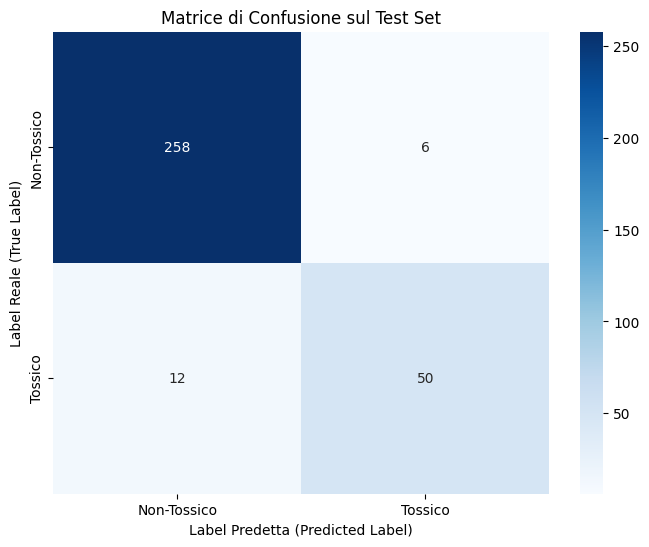

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assicurati che le variabili 'true_labels' e 'predicted_labels'
# siano state definite nel blocco di codice precedente.

# 1. Calcolare la matrice di confusione
cm = confusion_matrix(true_labels, predicted_labels)

# 2. Definire le etichette per gli assi (personalizzale se necessario)
# Assumiamo che 0 = Non-Tossico e 1 = Tossico
class_labels = ['Non-Tossico', 'Tossico']

# 3. Creare il grafico (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

# 4. Aggiungere titoli e label per chiarezza
plt.title('Matrice di Confusione sul Test Set')
plt.ylabel('Label Reale (True Label)')
plt.xlabel('Label Predetta (Predicted Label)')

# 5. Mostrare il grafico
plt.show()